<a href="https://colab.research.google.com/github/Uzema/dsp-seminars/blob/nikolaev_lab4/seminars/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009]
2000


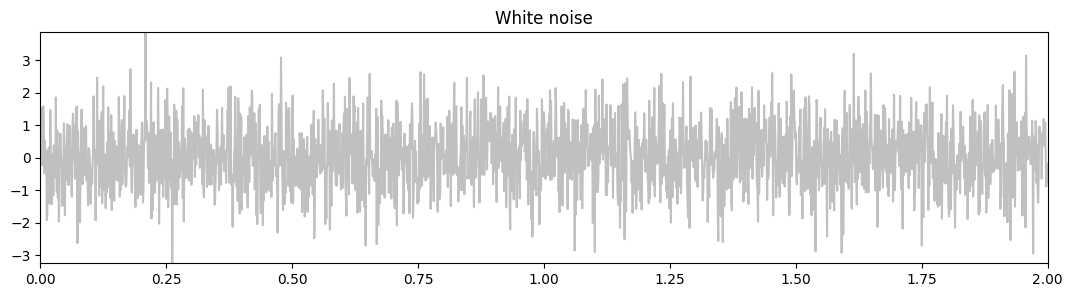

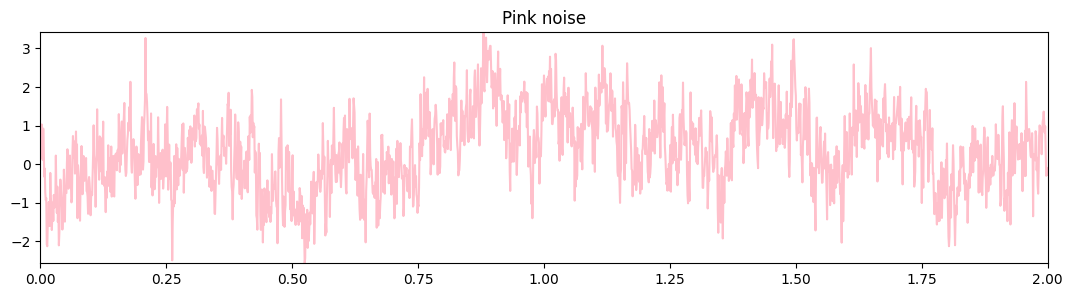

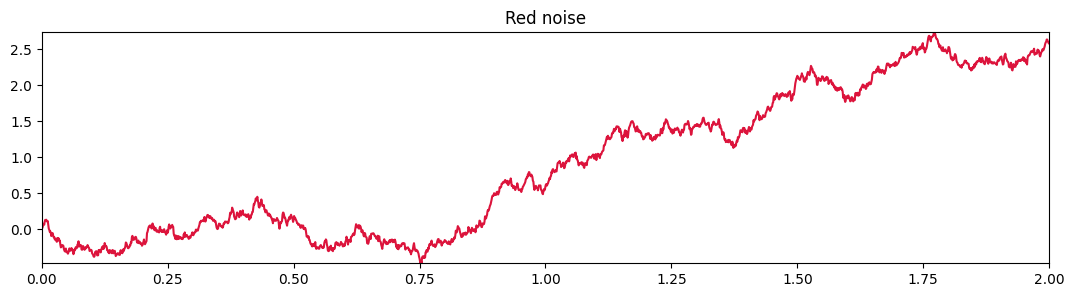

Белый шум: среднее:0.0450841465357407, дисперсия: 0.9765758247496166
Розовый шум: среднее:0.3688464579286591, дисперсия: 1.0000000000000002
Красный шум: среднее:0.8946549409027164, дисперсия: 0.9999999999999999


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

T = 2
fs = 1000
t = np.arange(0, 2, 1/fs)
print(t[:10])
print(len(t))
disp = 1

#white noise
white_noise = np.random.normal(0, disp, fs * T )

#pink noise
X = np.fft.rfft(white_noise)
freqs = np.fft.rfftfreq(len(white_noise), 1/fs)
X[1:] /= np.sqrt(freqs[1:])
pink_noise = np.fft.irfft(X)
pink_noise = pink_noise / np.std(pink_noise)

#red noise
red_noise = np.cumsum(white_noise)
red_noise = red_noise / np.std(red_noise)

plt.figure(figsize=(13, 3))
plt.title('White noise')
plt.plot(t, white_noise, color='silver')
plt.xlim(0,2)
plt.ylim(np.min(white_noise), np.max(white_noise))
plt.show()

plt.figure(figsize=(13, 3))
plt.title('Pink noise')
plt.plot(t, pink_noise, color='pink')
plt.xlim(0,2)
plt.ylim(np.min(pink_noise), np.max(pink_noise))
plt.show()

plt.figure(figsize=(13, 3))
plt.title('Red noise')
plt.plot(t, red_noise, color='crimson')
plt.xlim(0,2)
plt.ylim(np.min(red_noise), np.max(red_noise))
plt.show()

print(f'Белый шум: среднее:{np.mean(white_noise)}, дисперсия: {np.var(white_noise)}')
print(f'Розовый шум: среднее:{np.mean(pink_noise)}, дисперсия: {np.var(pink_noise)}')
print(f'Красный шум: среднее:{np.mean(red_noise)}, дисперсия: {np.var(red_noise)}')

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


Белый шум похож на кучу острых пиков вокруг 0, розовый шум не такой колючий, а также имеет более длинные волны, красный шум наиболее плавный из трех и чем-то напоминает график акций или биткоина несколько лет назад :P
Для белого шума среднее значение близко к 0, так что совпадает. Для розового шума среднее уже чуть выше, из-за того что розовый фильтр усиливает любое отклоенение среднего в белом шуме. В красном шуме среднее выше 0.8 из-за того, что красный шум это `cumsum`, тоесть накопленная сумма.

Для всех шумов дисперсия близка к 1, что совпадает с теоретическим значением.

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


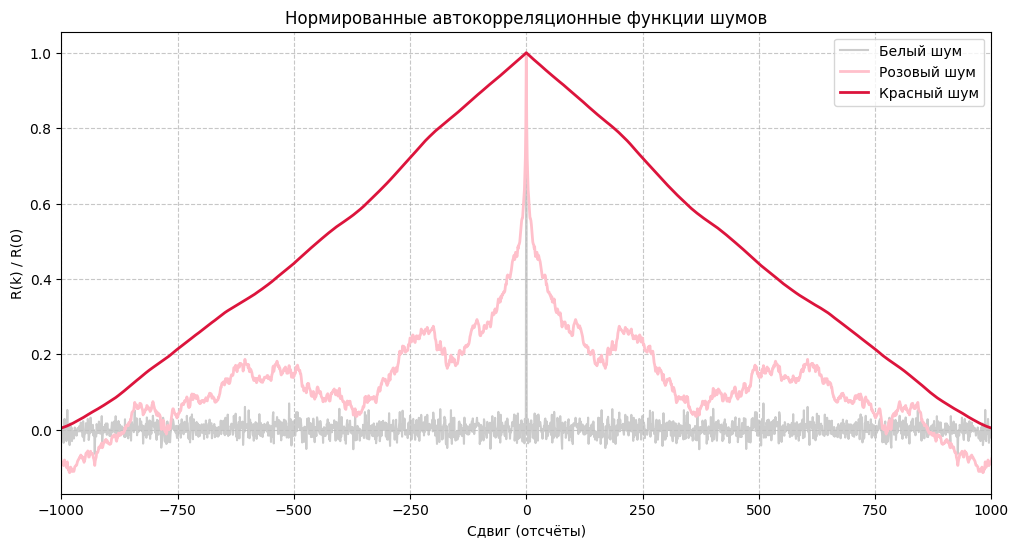

In [2]:
def get_normalized_acf(signal):
    # Вычисляем АКФ
    acf = np.correlate(signal, signal, mode='full')

    # Центрируем (индекс нулевого сдвига — это len(signal) - 1)
    center_idx = len(signal) - 1

    # Нормируем на значение при нулевом сдвиге (максимум)
    acf_norm = acf / acf[center_idx]

    # Создаем массив сдвигов (lags)
    lags = np.arange(-center_idx, center_idx + 1)

    return lags, acf_norm

# Вычисляем АКФ для каждого шума
lags_white, acf_white = get_normalized_acf(white_noise)
lags_pink, acf_pink = get_normalized_acf(pink_noise)
lags_red, acf_red = get_normalized_acf(red_noise)

# Визуализация
plt.figure(figsize=(12, 6))

# Рисуем все три на одном графике
plt.plot(lags_white, acf_white, label='Белый шум', color='silver', alpha=0.8)
plt.plot(lags_pink, acf_pink, label='Розовый шум', color='pink', linewidth=2)
plt.plot(lags_red, acf_red, label='Красный шум', color='crimson', linewidth=2)

# Ограничим масштаб по оси X для наглядности (например, +/- 500 отсчетов)
plt.xlim(-1000, 1000)
plt.title('Нормированные автокорреляционные функции шумов')
plt.xlabel('Сдвиг (отсчёты)')
plt.ylabel('R(k) / R(0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


* У белого шума акф похожа на иглу, корреляция падает до нуля при малейшем сдвиге. Отсутствие гладкости означает отсутствие зависимости между соседними точками.
* У розового шума пик акф шире, тоесть сигнал более предсказуем на коротких отрезках времени.
* Акф красного шума похоже на треугольник с очень широким основнием. Его гладкость означает сильную корреляцию между соседними отсчетами, что справедливо потому что красный шум это `cumsum`.

Форма акф показывает связь между значениями сигнала в разные моменты времени.

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


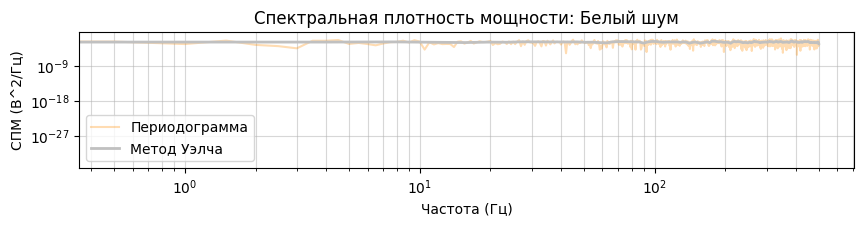

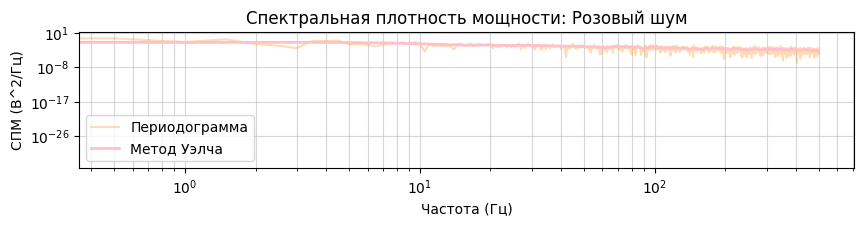

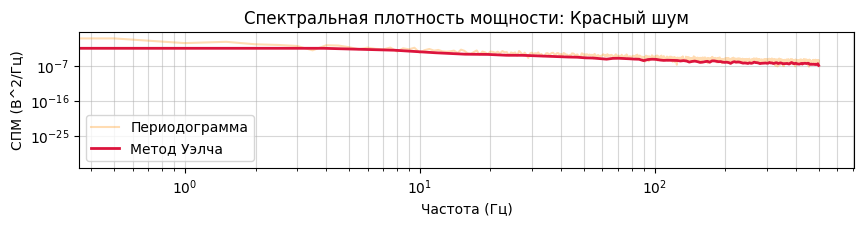

In [3]:
from scipy import signal

def plot_psd(noise_signal, fs, title, color):
    # 1. Вычисление периодограммы
    f_per, pxx_per = signal.periodogram(noise_signal, fs)

    # 2. Вычисление методом Уэлча
    # nperseg=256 — размер окна, noverlap=128 — перекрытие в 50%
    f_welch, pxx_welch = signal.welch(noise_signal, fs, window='hann',
                                      nperseg=256, noverlap=128)

    #plt.figure(figsize=(10, 5))
    plt.figure(figsize=(10, 6))
    plt.subplot(3, 1, 1)

    # Строим в логарифмическом масштабе
    plt.loglog(f_per, pxx_per, color='darkorange', alpha=0.3, label='Периодограмма')
    plt.loglog(f_welch, pxx_welch, color=color, linewidth=2, label='Метод Уэлча')

    plt.title(f'Спектральная плотность мощности: {title}')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('СПМ (В^2/Гц)')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()

# Запускаем расчет для каждого вида шума
plot_psd(white_noise, fs, 'Белый шум', 'silver')
plot_psd(pink_noise, fs, 'Розовый шум', 'pink')
plot_psd(red_noise, fs, 'Красный шум', 'crimson')

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


У белого шума она выглядит как прямая линия, у розового и красного шума они тоже прямые линии, но под небольшим наклоном. Теоретически так и должны, потому что СПМ описывается законом
$S(f)=1/f_\alpha​$,
а в двойном логарифмических масштабе
$log(S(f)) = log(1) - \alpha \cdot log(f) = - \alpha \cdot log(f)$, это уравнение прямой $y=k \cdot x$, где $k=- \alpha$

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


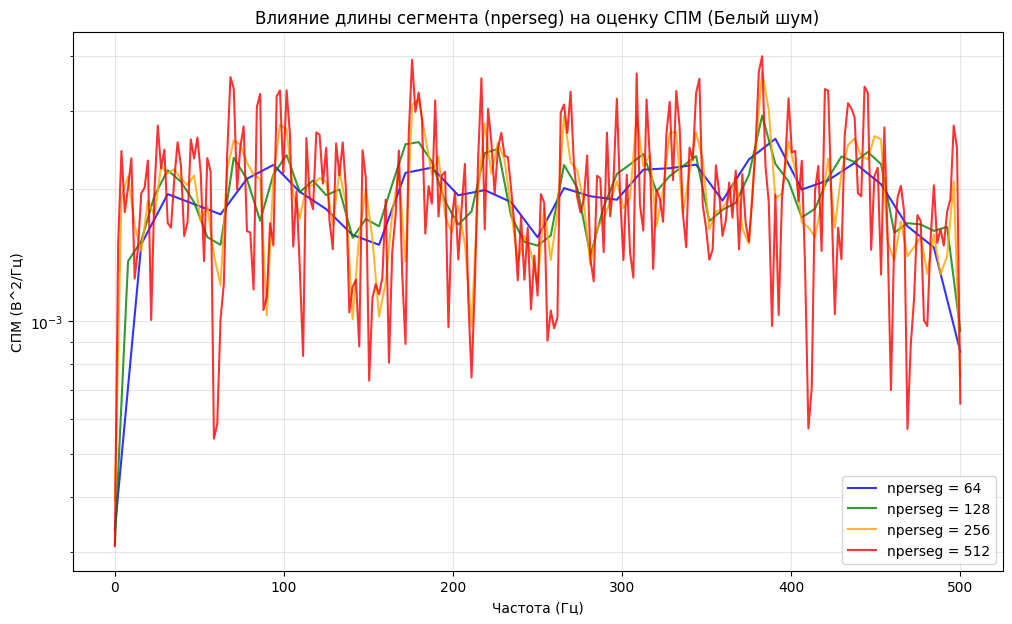

In [4]:
# Параметры
fs = 1000
nperseg_list = [64, 128, 256, 512]
colors = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(12, 7))

for nper, col in zip(nperseg_list, colors):
    # Вычисляем СПМ методом Уэлча
    # noverlap=nper//2 обеспечивает 50% перекрытие
    f, pxx = signal.welch(white_noise, fs, window='hann',
                          nperseg=nper, noverlap=nper//2)

    # Строим график (логарифмическая шкала по Y)
    plt.semilogy(f, pxx, label=f'nperseg = {nper}', color=col, alpha=0.8)

plt.title('Влияние длины сегмента (nperseg) на оценку СПМ (Белый шум)')
plt.xlabel('Частота (Гц)')
plt.ylabel('СПМ (В^2/Гц)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


Увелечене длины сегмента приводит к повышению частотного разрешения (пики становятся более узкими), гладкость становится хуже (дисперсия выше).

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

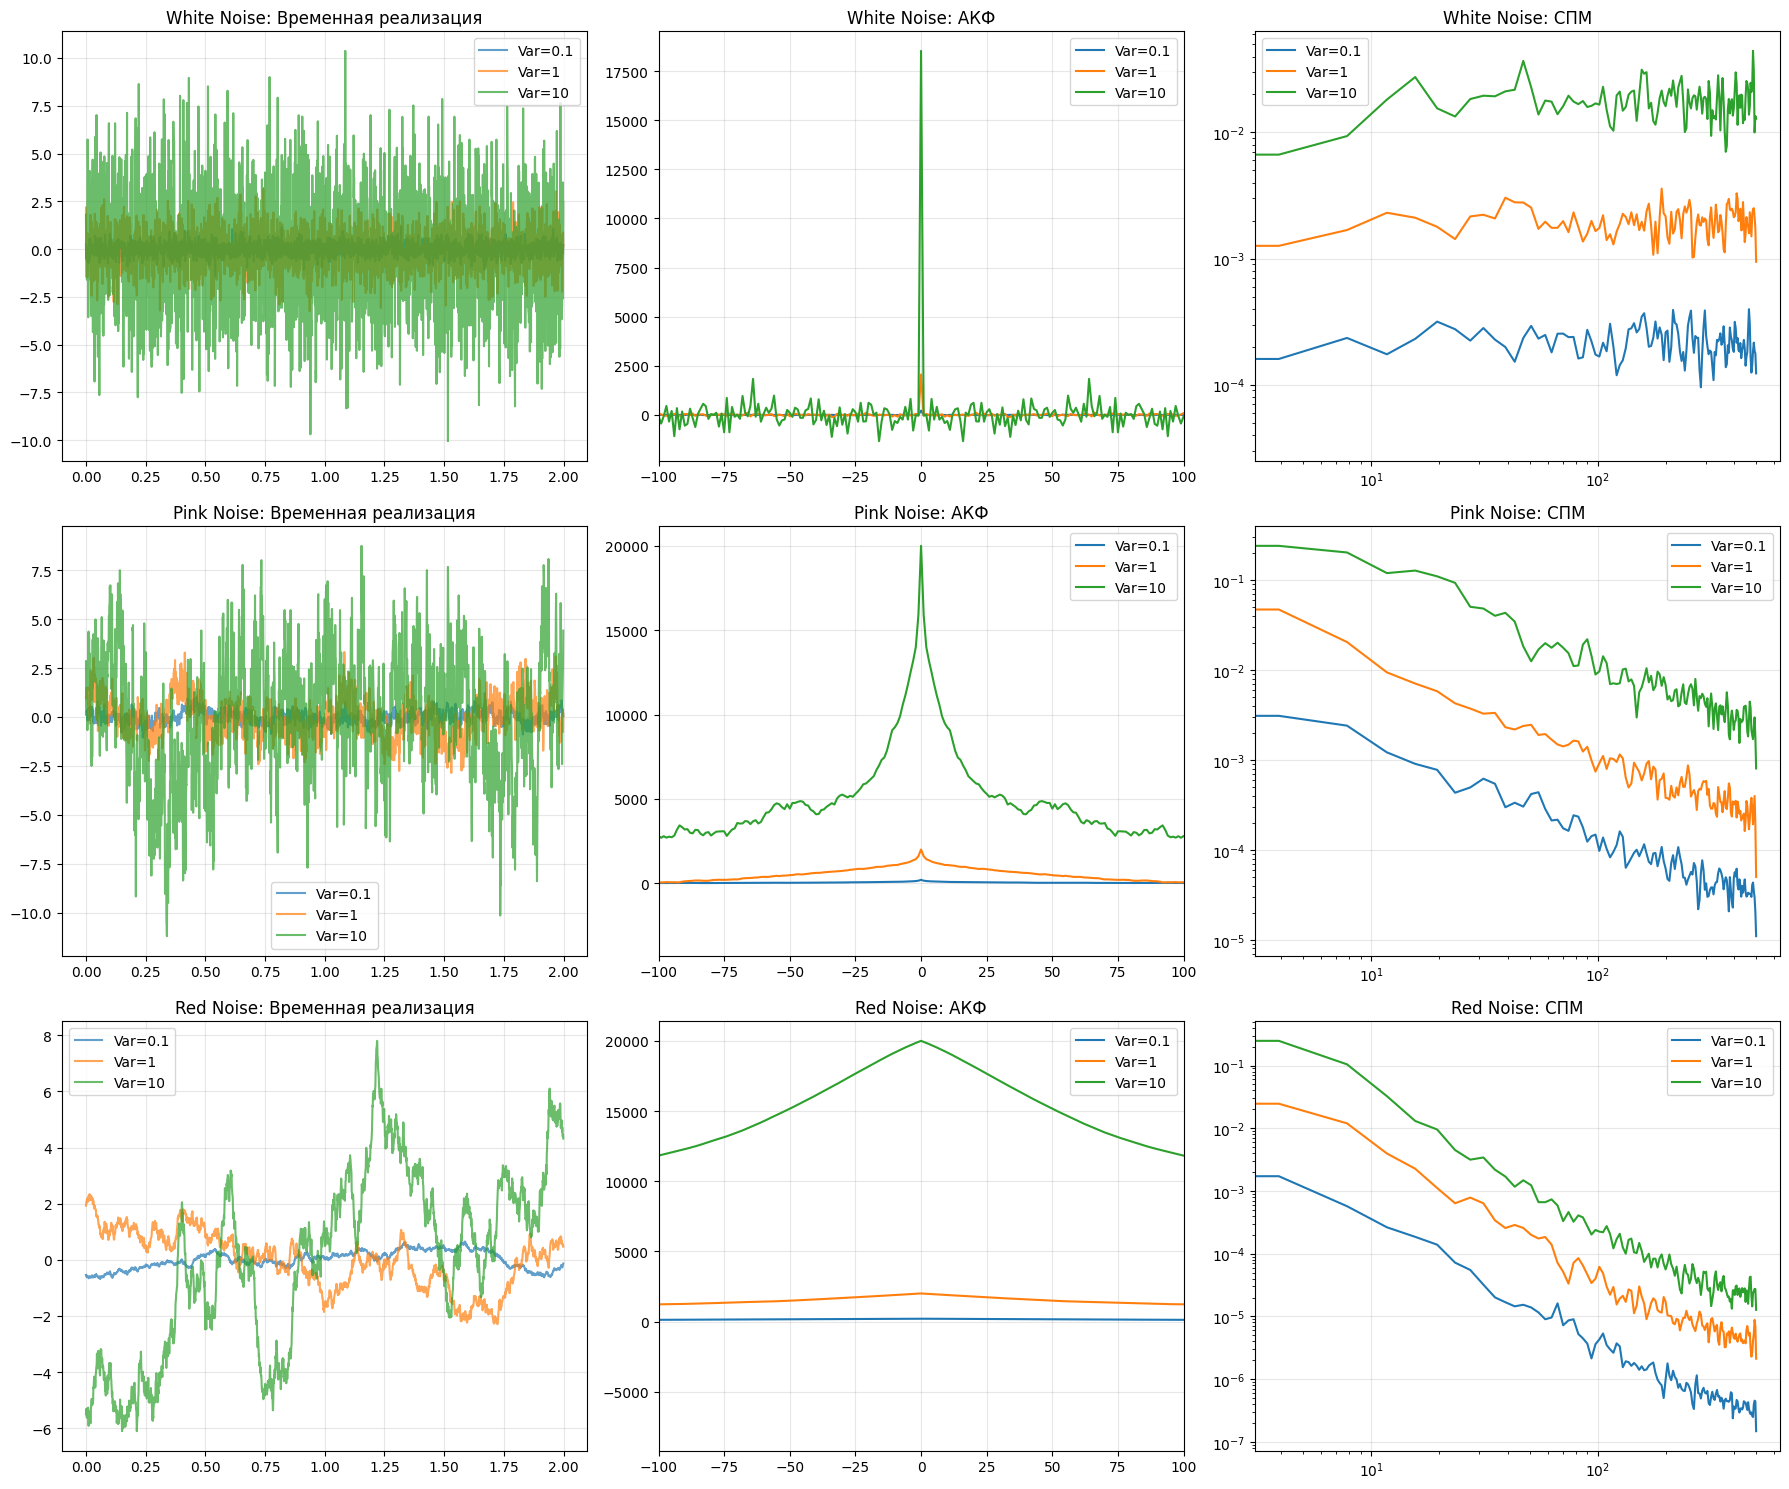

In [8]:
def get_noise_variations(noise_type, variances, fs=1000, T=2):
    N = fs * T
    t = np.arange(0, T, 1/fs)
    results = []

    for v in variances:
        # 1. Генерация (базовый белый шум всегда с дисперсией v)
        w = np.random.normal(0, np.sqrt(v), N)

        if noise_type == 'white':
            sig = w
        elif noise_type == 'pink':
            # Генерируем, нормализуем к 1, потом масштабируем к sqrt(v)
            X = np.fft.rfft(np.random.normal(0, 1, N))
            freqs = np.fft.rfftfreq(N, 1/fs)
            X[1:] /= np.sqrt(freqs[1:])
            sig = np.fft.irfft(X)
            sig = (sig - np.mean(sig)) / np.std(sig) * np.sqrt(v)
        elif noise_type == 'red':
            sig = np.cumsum(np.random.normal(0, 1, N))
            sig = (sig - np.mean(sig)) / np.std(sig) * np.sqrt(v)

        # 2. Вычисление АКФ
        acf = np.correlate(sig, sig, mode='full')
        lags = np.arange(-N+1, N)

        # 3. Вычисление СПМ
        f, pxx = signal.welch(sig, fs, nperseg=256)

        results.append((sig, lags, acf, f, pxx))
    return t, results

variances = [0.1, 1, 10]
noises = ['white', 'pink', 'red']
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for i, nt in enumerate(noises):
    t, res = get_noise_variations(nt, variances)

    for j, (sig, lags, acf, f, pxx) in enumerate(res):
        v_label = f'Var={variances[j]}'

        # Временная реализация
        axes[i, 0].plot(t, sig, label=v_label, alpha=0.7)
        axes[i, 0].set_title(f'{nt.capitalize()} Noise: Временная реализация')

        # АКФ (зум в центр)
        axes[i, 1].plot(lags, acf, label=v_label)
        axes[i, 1].set_xlim(-100, 100)
        axes[i, 1].set_title(f'{nt.capitalize()} Noise: АКФ')

        # СПМ
        axes[i, 2].loglog(f, pxx, label=v_label)
        axes[i, 2].set_title(f'{nt.capitalize()} Noise: СПМ')

for ax_row in axes:
    for ax in ax_row:
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


* Для временной реализации:
амплитуда сигнала возрастает
* Для АКФ: меняется высота центрального пика
* Для СПМ: меняется вертикальное положение всей кривой на графике

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


In [6]:
# Ваш код здесь

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


{Введите ваш ответ здесь}

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


In [7]:
# Ваш код здесь

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


{Введите ваш ответ здесь}